# Weak Overlap Level and ATE RMSE

# Packages & Utils

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import arrow
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from engression import engression

from utils.dgp import generate_data
from utils.dgp import introduce_weak_overlap

In [2]:
sns.set_theme(style="whitegrid")
np.random.seed(123)
torch.manual_seed(123)

In [3]:
def to_csv_w_suffix(df, filename, suffix=None):
    if suffix is None:
        suffix = arrow.now().format("YYYY-MM-DD-hh-mm")
    output_file = f"{filename}-{suffix}.csv"
    df.to_csv(output_file, index=False)
    return

In [4]:
def get_xy(df, include_treat=False):
    X = df[feature_cols].to_numpy(dtype=float)
    T = df[treat_col].to_numpy(dtype=float)
    Y = df[outcome_col].to_numpy(dtype=float)
    if include_treat:
        X = np.column_stack([X, T])
    return X, T, Y

def clip_ps(ps, eps=0.01):
    return np.clip(ps, eps, 1 - eps)

def fit_propensity_logit(df):
    X, T, _ = get_xy(df, include_treat=False)
    ps_model = LogisticRegression(max_iter=3000)
    ps_model.fit(X, T)
    ps_hat = ps_model.predict_proba(X)[:, 1]
    return ps_model, clip_ps(ps_hat)

def ate_from_mu(mu0, mu1):
    return np.mean(mu1 - mu0)

def ipw_ate(y, t, ps):
    return np.mean(t * y / ps - (1 - t) * y / (1 - ps))

def aipw_ate(y, t, ps, mu0, mu1):
    score = (
        (mu1 - mu0)
        + t * (y - mu1) / ps
        - (1 - t) * (y - mu0) / (1 - ps)
    )
    return np.mean(score)

def summarize_against_truth(estimates, true_ate=None):
    out = pd.DataFrame({
        "method": list(estimates.keys()),
        "estimate": list(estimates.values())
    })
    if true_ate is not None:
        out["true_ate"] = true_ate
        out["error"] = out["estimate"] - true_ate
        out["abs_error"] = out["error"].abs()
    return out.sort_values("estimate").reset_index(drop=True)

In [60]:
feature_cols = [c for c in bdf.columns if c.lower().startswith("x")]

treat_col = "T"
outcome_col = "Y"

true_cate_col = "true_cate" if "true_cate" in bdf.columns else None
true_ps_col = "propensity" if "propensity" in bdf.columns else None

print("feature_cols:", feature_cols)
print("true_cate_col:", true_cate_col)
print("true_ps_col:", true_ps_col)

feature_cols: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25']
true_cate_col: None
true_ps_col: None


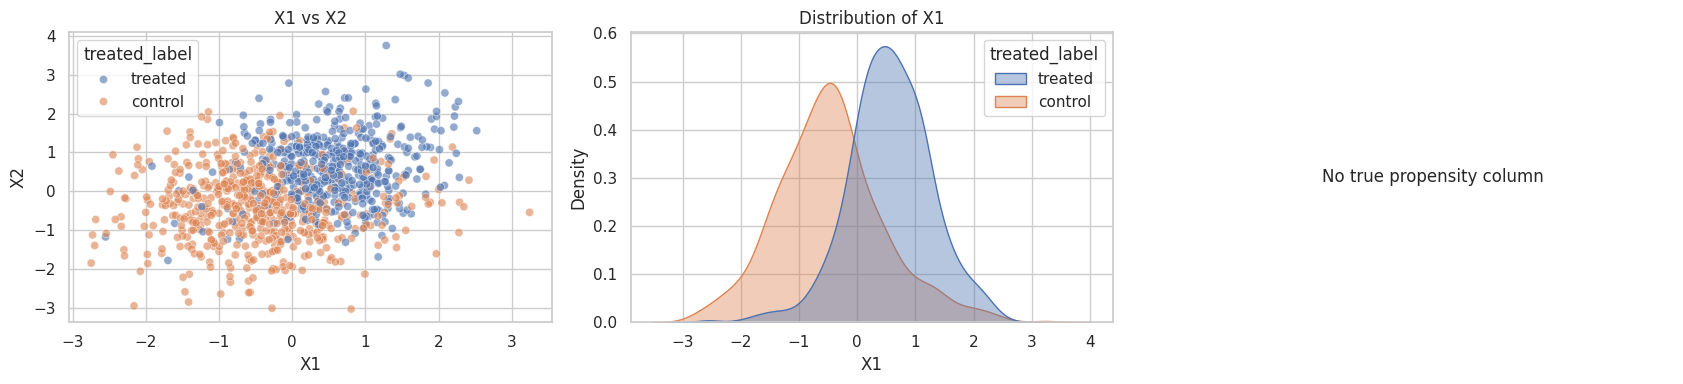

In [61]:
plot_df = bdf.copy()
plot_df["treated_label"] = np.where(plot_df[treat_col] == 1, "treated", "control")

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

if len(feature_cols) >= 2:
    sns.scatterplot(
        data=plot_df, x=feature_cols[0], y=feature_cols[1],
        hue="treated_label", alpha=0.6, s=35, ax=axes[0]
    )
    axes[0].set_title(f"{feature_cols[0]} vs {feature_cols[1]}")
else:
    axes[0].text(0.5, 0.5, "Need at least 2 X columns", ha="center", va="center")
    axes[0].set_axis_off()

sns.kdeplot(
    data=plot_df, x=feature_cols[0], hue="treated_label",
    fill=True, common_norm=False, alpha=0.4, ax=axes[1]
)
axes[1].set_title(f"Distribution of {feature_cols[0]}")

if true_ps_col is not None:
    sns.kdeplot(
        data=plot_df, x=true_ps_col, hue="treated_label",
        fill=True, common_norm=False, alpha=0.4, ax=axes[2]
    )
    axes[2].set_title("True propensity distribution")
else:
    axes[2].text(0.5, 0.5, "No true propensity column", ha="center", va="center")
    axes[2].set_axis_off()

plt.tight_layout()
plt.savefig("cov-dist.png")
plt.show()

## 2. Estimations

### S-learner
Single model for $P(Y \mid X, T)$

### T-learner
Two models for $P(Y \mid X, T=1), P(Y \mid X, T=0)$

## 3.1 Linear Regressions

In [5]:
def fit_ols_s_learner(df):
    X_st, T, Y = get_xy(df, include_treat=True)
    model = LinearRegression().fit(X_st, Y)

    X1 = X_st.copy()
    X0 = X_st.copy()
    X1[:, -1] = 1.0
    X0[:, -1] = 0.0

    mu1 = model.predict(X1)
    mu0 = model.predict(X0)
    return model, mu0, mu1


def fit_ridge_s_learner(df):
    X_st, T, Y = get_xy(df, include_treat=True)
    model = Ridge(alpha=1.0).fit(X_st, Y)

    X1 = X_st.copy()
    X0 = X_st.copy()
    X1[:, -1] = 1.0
    X0[:, -1] = 0.0

    mu1 = model.predict(X1)
    mu0 = model.predict(X0)
    return model, mu0, mu1

def fit_ols_t_learner(df):
    X, T, Y = get_xy(df, include_treat=False)
    model0 = LinearRegression().fit(X[T == 0], Y[T == 0])
    model1 = LinearRegression().fit(X[T == 1], Y[T == 1])

    mu0 = model0.predict(X)
    mu1 = model1.predict(X)
    return (model0, model1), mu0, mu1

## 3.2 Random Forest Regressor w/ AIPW

In [6]:
def fit_rf_s_learner(df):

    X_st, T, Y = get_xy(df, include_treat=True)
    model = RandomForestRegressor().fit(X_st, Y)

    X1 = X_st.copy()
    X0 = X_st.copy()
    X1[:, -1] = 1.0
    X0[:, -1] = 0.0

    mu1 = model.predict(X1)
    mu0 = model.predict(X0)

    return model, mu0, mu1


def fit_rf_t_learner(df):
    
    X, T, Y = get_xy(df, include_treat=False)

    treated_mask = (T == 1)
    control_mask = (T == 0)

    X1_train = X[treated_mask]
    Y1_train = Y[treated_mask]

    X0_train = X[control_mask]
    Y0_train = Y[control_mask]

    model1 = RandomForestRegressor().fit(X1_train, Y1_train)
    model0 = RandomForestRegressor().fit(X0_train, Y0_train)

    mu1 = model1.predict(X)
    mu0 = model0.predict(X)

    return (model0, model1), mu0, mu1

## 3.3 Engression outcome models

In [7]:
def to_torch(x):
    return torch.from_numpy(np.asarray(x)).to(torch.float32)

def fit_engression_s_learner(
    df,
    lr=0.01,
    num_epochs=600,
    batch_size=512,
    sample_size=200,
    device="cpu",
    verbose=True
):
    X_st, T, Y = get_xy(df, include_treat=True)
    X_torch = to_torch(X_st)
    Y_torch = to_torch(Y.reshape(-1, 1))

    model = engression(
        X_torch,
        Y_torch,
        lr=lr,
        num_epochs=num_epochs,
        batch_size=batch_size,
        device=device,
        verbose=verbose
    )

    X1 = X_torch.clone()
    X0 = X_torch.clone()
    X1[:, -1] = 1.0
    X0[:, -1] = 0.0

    mu1 = model.predict(X1, target="mean", sample_size=sample_size).reshape(-1).cpu().numpy()
    mu0 = model.predict(X0, target="mean", sample_size=sample_size).reshape(-1).cpu().numpy()
    return model, mu0, mu1

def fit_engression_t_learner(
    df,
    lr=0.01,
    num_epochs=600,
    batch_size=512,
    sample_size=200,
    device="cpu",
    verbose=True
):
    X, T, Y = get_xy(df, include_treat=False)
    X_torch = to_torch(X)
    Y_torch = to_torch(Y.reshape(-1, 1))
    T_bool = T.astype(bool)

    model0 = engression(
        X_torch[~T_bool],
        Y_torch[~T_bool],
        lr=lr,
        num_epochs=num_epochs,
        batch_size=batch_size,
        device=device,
        verbose=verbose
    )
    model1 = engression(
        X_torch[T_bool],
        Y_torch[T_bool],
        lr=lr,
        num_epochs=num_epochs,
        batch_size=batch_size,
        device=device,
        verbose=verbose
    )

    mu0 = model0.predict(X_torch, target="mean", sample_size=sample_size).reshape(-1).cpu().numpy()
    mu1 = model1.predict(X_torch, target="mean", sample_size=sample_size).reshape(-1).cpu().numpy()
    return (model0, model1), mu0, mu1

In [ ]:
def run_single_experiment(
    df,
    eng_num_epochs=500,
    eng_batch_size=512,
    eng_lr=0.01,
    eng_sample_size=200,
    ps_source="estimated",
    device="cpu",
    verbose=True
):
    X, T, Y = get_xy(df, include_treat=False)

    # Propensity score
    _, ps_hat = fit_propensity_logit(df)
    if ps_source == "true" and true_ps_col is not None:
        ps = clip_ps(df[true_ps_col].to_numpy())
    else:
        ps = ps_hat

    # OLS
    _, mu0_ols_s, mu1_ols_s = fit_ols_s_learner(df)
    _, mu0_ols_t, mu1_ols_t = fit_ols_t_learner(df)

    # Ridge
    _, mu0_ridge, mu1_ridge = fit_ridge_s_learner(df)


    # Random Forest
    _, mu0_rf_s, mu1_rf_s = fit_rf_s_learner(df)
    _, mu0_rf_t, mu1_rf_t = fit_rf_t_learner(df)

    # Engression
    _, mu0_eng_s, mu1_eng_s = fit_engression_s_learner(
        df,
        lr=eng_lr,
        num_epochs=eng_num_epochs,
        batch_size=eng_batch_size,
        sample_size=eng_sample_size,
        device=device,
        verbose=verbose
    )
    _, mu0_eng_t, mu1_eng_t = fit_engression_t_learner(
        df,
        lr=eng_lr,
        num_epochs=eng_num_epochs,
        batch_size=eng_batch_size,
        sample_size=eng_sample_size,
        device=device,
        verbose=verbose
    )

    estimates = {
        "OLS_S_direct": ate_from_mu(mu0_ols_s, mu1_ols_s),
        "OLS_T_direct": ate_from_mu(mu0_ols_t, mu1_ols_t),
        "IPW": ipw_ate(Y, T, ps),
        "AIPW_OLS_S": aipw_ate(Y, T, ps, mu0_ols_s, mu1_ols_s),
        "AIPW_OLS_T": aipw_ate(Y, T, ps, mu0_ols_t, mu1_ols_t),
        "AIPW_Ridge_S": aipw_ate(Y, T, ps, mu0_ridge, mu1_ridge),
        "AIPW_RF_S": aipw_ate(Y, T, ps, mu0_rf_s, mu1_rf_s),
        "AIPW_RF_T": aipw_ate(Y, T, ps, mu0_rf_t, mu1_rf_t),
        "Eng_S_direct": ate_from_mu(mu0_eng_s, mu1_eng_s),
        "Eng_T_direct": ate_from_mu(mu0_eng_t, mu1_eng_t),
        "AIPW_Eng_S": aipw_ate(Y, T, ps, mu0_eng_s, mu1_eng_s),
        "AIPW_Eng_T": aipw_ate(Y, T, ps, mu0_eng_t, mu1_eng_t),
    }

    true_ate = df[true_cate_col].mean() if true_cate_col is not None else None
    res = summarize_against_truth(estimates, true_ate=true_ate)
    res['true_ate'] = 1.1028
    res['bias'] = res.estimate - res.true_ate
    res['abs_error'] = abs(res.estimate - res.true_ate)
    return res

# 4. Monte-Carlo Simulation

In [17]:
from tqdm import tqdm

def run_mc(
    df,
    n_rep=10,
    eng_num_epochs=500,
    eng_batch_size=512,
    eng_lr=0.01,
    eng_sample_size=1000,
    device="cpu",
    verbose=True
):
    rows = []
    for rep in tqdm(range(n_rep)):
        # df = simulator_fn(seed=1000 + rep)
        one = run_single_experiment(
            df,
            eng_num_epochs=eng_num_epochs,
            eng_batch_size=min(eng_batch_size, len(df)),
            eng_lr=eng_lr,
            eng_sample_size=eng_sample_size,
            device=device,
            verbose=verbose
        ).copy()
        one["rep"] = rep
        rows.append(one)
    return pd.concat(rows, ignore_index=True)

# Example usage:
# mc_res = run_mc(bdf, verbose=False)

## Different Gammas

In [18]:
df_list = []
for gamma in [2.0, 6.0, 8.0, 10.0, 20.0]:
    print(f"Start running for gamma = {gamma} ============")
    bdf = introduce_weak_overlap(df, true_ate=true_ate, gamma=gamma, seed=538)
    feature_cols = [c for c in bdf.columns if c.lower().startswith("x")]

    treat_col = "T"
    outcome_col = "Y"
    true_cate_col = "true_cate" if "true_cate" in bdf.columns else None
    true_ps_col = "propensity" if "propensity" in bdf.columns else None

    

    mc_res = run_mc(bdf, n_rep=30, verbose=False)
    report = mc_res.groupby(['method']).agg(
        n=('abs_error', 'count'),
        mae=('abs_error', 'mean'),
        rmse=('abs_error', lambda x: np.sqrt(np.mean(np.square(x))))
    ).reset_index().sort_values('rmse')
    report['gamma'] = gamma
    df_list.append(report)

Start running for gamma = 2.0 ============
Samples       : 1042  (dropped 958 of 2000)
Gamma         : 2.0
Covariates    : 25
Treated units : 458  (44.0%)
Control units : 584  (56.0%)
True ATE      : 1.1028
E[e(X)]       : 0.4413
Y mean        : 1.5299
Y std         : 1.7473
e(X) < 0.1    : 16.4% of surviving units
e(X) > 0.9    : 1.2% of surviving units
0.1–0.9       : 82.3% of surviving units


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [13:42<00:00, 27.40s/it]


Start running for gamma = 6.0 ============
Samples       : 1059  (dropped 941 of 2000)
Gamma         : 6.0
Covariates    : 25
Treated units : 474  (44.8%)
Control units : 585  (55.2%)
True ATE      : 1.1028
E[e(X)]       : 0.4558
Y mean        : 1.5924
Y std         : 1.8120
e(X) < 0.1    : 35.5% of surviving units
e(X) > 0.9    : 25.1% of surviving units
0.1–0.9       : 39.4% of surviving units


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [13:57<00:00, 27.92s/it]


Start running for gamma = 8.0 ============
Samples       : 1071  (dropped 929 of 2000)
Gamma         : 8.0
Covariates    : 25
Treated units : 484  (45.2%)
Control units : 587  (54.8%)
True ATE      : 1.1028
E[e(X)]       : 0.4604
Y mean        : 1.6263
Y std         : 1.8322
e(X) < 0.1    : 40.1% of surviving units
e(X) > 0.9    : 30.2% of surviving units
0.1–0.9       : 29.7% of surviving units


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [14:06<00:00, 28.22s/it]


Start running for gamma = 10.0 ============
Samples       : 1061  (dropped 939 of 2000)
Gamma         : 10.0
Covariates    : 25
Treated units : 488  (46.0%)
Control units : 573  (54.0%)
True ATE      : 1.1028
E[e(X)]       : 0.4620
Y mean        : 1.6236
Y std         : 1.8409
e(X) < 0.1    : 42.6% of surviving units
e(X) > 0.9    : 33.5% of surviving units
0.1–0.9       : 23.9% of surviving units


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [32:13<00:00, 64.46s/it]


Start running for gamma = 20.0 ============
Samples       : 1062  (dropped 938 of 2000)
Gamma         : 20.0
Covariates    : 25
Treated units : 496  (46.7%)
Control units : 566  (53.3%)
True ATE      : 1.1028
E[e(X)]       : 0.4680
Y mean        : 1.6390
Y std         : 1.8527
e(X) < 0.1    : 47.6% of surviving units
e(X) > 0.9    : 40.6% of surviving units
0.1–0.9       : 11.9% of surviving units


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [22:14<00:00, 44.49s/it]


In [19]:
all_df = pd.concat(df_list).reset_index(drop=True)

In [20]:
subset_df = all_df[all_df.method.str.contains("Eng")]

In [21]:
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

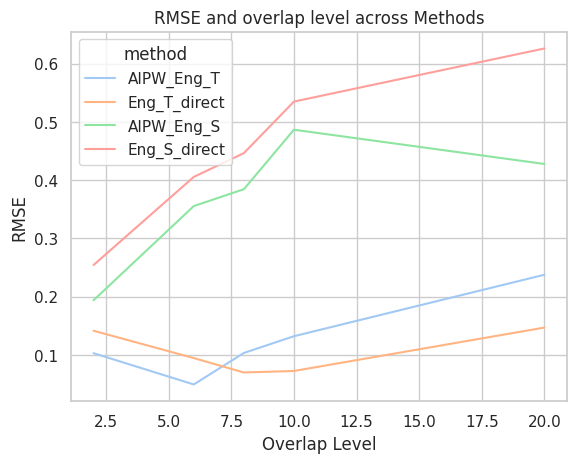

In [26]:
sns.lineplot(x='gamma', y='rmse', hue='method', palette='pastel', data=subset_df)
# plt.legend(bbox_to_anchor=(0, 1))
plt.title("RMSE and overlap level across Methods")
plt.ylabel("RMSE")
plt.xlabel("Overlap Level")
plt.savefig("RMSE-overlap-plot.png")
plt.show()